# Citi Bike Trip Data (2024-01) — EDA
Following `docs/eda_checklist.md`.

Source: Citi Bike NYC system data (`citibikenyc.com/system-data`), direct S3 download, one representative month (2024-01, split by the publisher into 2 CSVs since it exceeds 1M rows).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import glob

DATA_DIR = "../../data/raw/ride/citibike/202401"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
files = sorted(glob.glob(f"{DATA_DIR}/*.csv"))
print(files)
df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
print("shape:", df.shape)
df.head()

['../../data/raw/ride/citibike/202401\\202401-citibike-tripdata_1.csv', '../../data/raw/ride/citibike/202401\\202401-citibike-tripdata_2.csv']


shape: (1888085, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,8E865410DBDE0CA9,electric_bike,2024-01-01 13:00:04.563,2024-01-01 13:04:04.652,3 St & 3 Ave,4028.03,Carroll St & Smith St,4225.14,40.675070,-73.987752,40.680611,-73.994758,casual
1,0403D0B3FC9CA77D,electric_bike,2024-01-08 19:36:43.520,2024-01-08 19:53:16.266,Franklin Ave & St Marks Ave,4107.05,Bedford Ave & Bergen St,4066.15,40.675832,-73.956168,40.676368,-73.952918,casual
2,F6DE7BB42FF550BE,electric_bike,2024-01-12 15:00:41.580,2024-01-12 15:36:29.622,W 67 St & Broadway,7116.04,Central Park W & W 103 St,7577.27,40.774925,-73.982666,40.795590,-73.961884,casual
3,84A995BFD98030D4,classic_bike,2024-01-12 16:52:19.025,2024-01-12 17:17:29.773,Central Park West & W 68 St,7079.06,E 5 St & Ave C,5545.04,40.773407,-73.977825,40.722992,-73.979955,member
4,7BBEAD4F2B535813,electric_bike,2024-01-05 19:50:19.202,2024-01-05 20:34:42.517,W 67 St & Broadway,7116.04,Ave A & E 14 St,5779.11,40.774925,-73.982666,40.730311,-73.980472,member


In [3]:
df.dtypes

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object

## 2. Missing Values

In [4]:
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

end_station_name      0.29
end_lat               0.29
end_lng               0.29
end_station_id        0.29
start_station_name    0.06
start_lat             0.06
start_station_id      0.06
start_lng             0.06
ride_id               0.00
ended_at              0.00
started_at            0.00
rideable_type         0.00
member_casual         0.00
dtype: float64

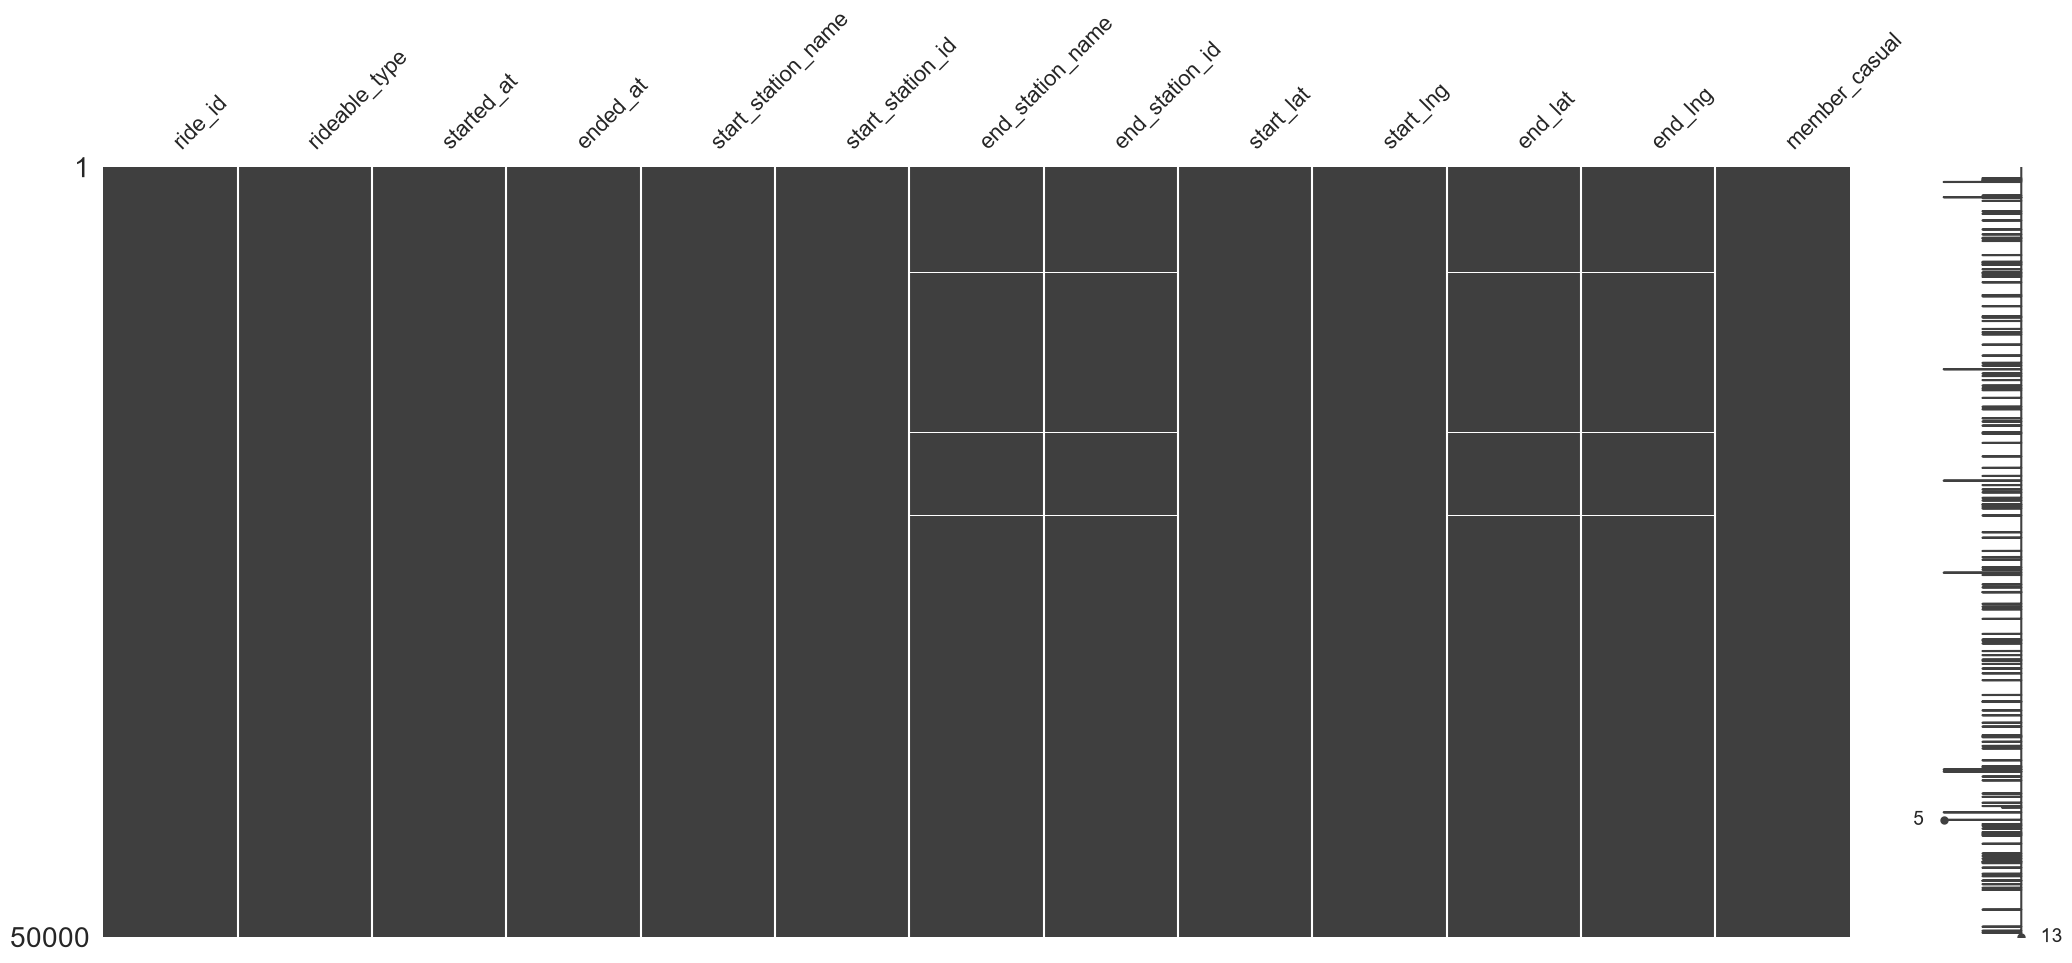

In [5]:
msno.matrix(df.sample(50_000, random_state=0)); plt.show()

Decision: `end_station_*` (0.29%) and `start_station_*` (0.06%) missing together (same rows) — these are trips that started/ended outside a formal dock (e.g. dockless e-bike parking), a real operational case, not a data error. Keep as "no station" category rather than drop.

## 3. Duplicates

In [6]:
print("full-row dup:", df.duplicated().sum())
print("dup ride_id:", df["ride_id"].duplicated().sum())

full-row dup: 0


dup ride_id: 0


## 4. Univariate Analysis

In [7]:
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])
df["duration_sec"] = (df["ended_at"] - df["started_at"]).dt.total_seconds()
df["duration_sec"].describe()

count    1.888085e+06
mean     6.909572e+02
std      2.027436e+03
min      6.004400e+01
25%      2.801280e+02
50%      4.645290e+02
75%      7.801150e+02
max      9.002953e+04
Name: duration_sec, dtype: float64

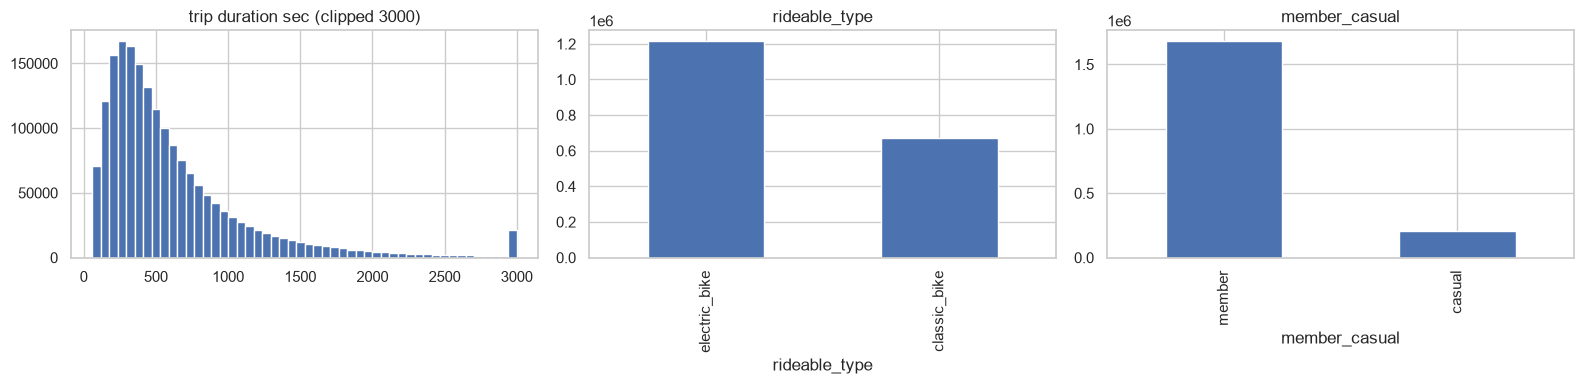

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df["duration_sec"].clip(0, 3000).hist(bins=50, ax=ax[0]); ax[0].set_title("trip duration sec (clipped 3000)")
df["rideable_type"].value_counts().plot(kind="bar", ax=ax[1]); ax[1].set_title("rideable_type")
df["member_casual"].value_counts().plot(kind="bar", ax=ax[2]); ax[2].set_title("member_casual")
plt.tight_layout(); plt.show()

## 5. Outliers

In [9]:
print("duration <= 0:", (df["duration_sec"] <= 0).sum())
print("duration < 60 (should be 0, publisher already filters):", (df["duration_sec"] < 60).sum())
print("duration > 3h:", (df["duration_sec"] > 3 * 3600).sum(), f"({(df['duration_sec'] > 3*3600).mean():.2%})")
print("duration max:", df["duration_sec"].max() / 3600, "hours")

duration <= 0: 0
duration < 60 (should be 0, publisher already filters): 0
duration > 3h: 2422 (0.13%)
duration max: 25.008203055555555 hours


Decision: `duration_sec` minimum is exactly 60s — confirms the publisher's own documented filter (trips under 60s, likely false starts, are already excluded). 0.13% of trips exceed 3 hours (long tail — bike left docked/lost, or a genuine long ride) — flag as outliers before duration-based features.

## 6. Target Variable

No single supervised target — closest recommendation-relevant signal is the (start_station, end_station) pair, checked in section 10.

## 7. Bivariate / Correlation Analysis

In [10]:
pd.crosstab(df["rideable_type"], df["member_casual"], normalize="index").round(3)

member_casual,casual,member
rideable_type,,
classic_bike,0.073,0.927
electric_bike,0.131,0.869


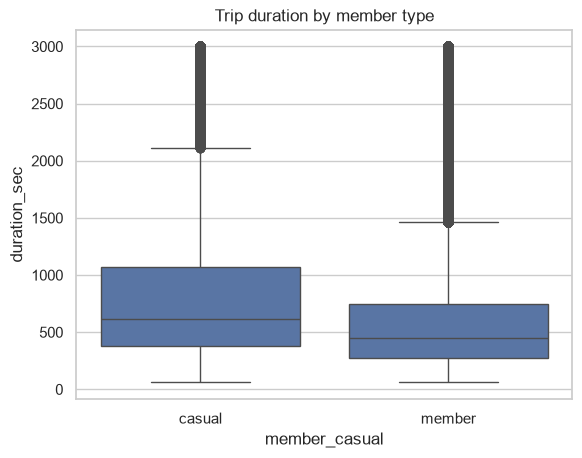

In [11]:
sns.boxplot(x=df["member_casual"], y=df["duration_sec"].clip(0, 3000))
plt.title("Trip duration by member type"); plt.show()

## 8. Time-based Checks

started_at range: 2023-12-31 02:36:55.648000 to 2024-01-31 23:58:30.270000


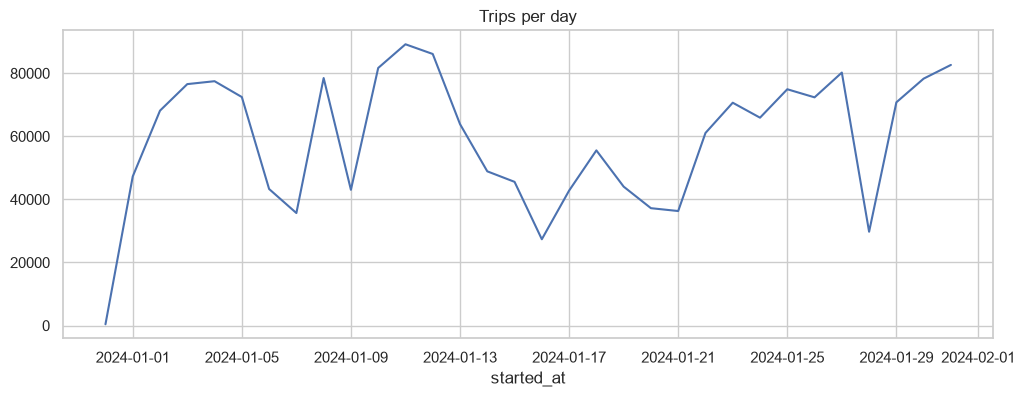

In [12]:
print("started_at range:", df["started_at"].min(), "to", df["started_at"].max())
df["started_at"].dt.date.value_counts().sort_index().plot(figsize=(12, 4), title="Trips per day")
plt.show()

Single month (Dec 31, 2023 – Jan 31, 2024) — matches the NYC TLC dataset's own scope limitation (1 month pulled). No multi-year seasonality visible from this pull alone; would need multiple months for RQ1's seasonal slicing.

## 9. Data Consistency

In [13]:
bbox = df[(df["start_lat"].between(40.4, 41.0)) & (df["start_lng"].between(-74.3, -73.6))]
print(f"start points inside real NYC bbox: {len(bbox)} / {df['start_lat'].notna().sum()} ({len(bbox)/df['start_lat'].notna().sum():.4%})")
print("n unique start_station_id:", df["start_station_id"].nunique())
print("n unique end_station_id:", df["end_station_id"].nunique())

start points inside real NYC bbox: 1886925 / 1886925 (100.0000%)
n unique start_station_id: 2223
n unique end_station_id: 2185


100% of GPS points fall inside the real NYC bounding box — genuine coordinates, unlike Akeed's synthetic ones.

## 10. Feature Relationships for Recommendation Context

In [14]:
d = df.dropna(subset=["start_station_id", "end_station_id"])
pairs = d.groupby(["start_station_id", "end_station_id"]).size()
n_start, n_end = d["start_station_id"].nunique(), d["end_station_id"].nunique()
sparsity = 1 - len(pairs) / (n_start * n_end)
print(f"station-pair core: {n_start} start stations, {n_end} end stations, {len(pairs)} unique pairs, sparsity {sparsity:.2%}")

per_start = d.groupby("start_station_id").size()
print("trips per start station: median", per_start.median(), "mean", round(per_start.mean(), 1))
print("stations with <=5 trips:", (per_start <= 5).sum(), f"({(per_start <= 5).mean():.1%})")
print()
print("NOTE: there is no rider/user identifier anywhere in this file -- member_casual is only a 2-value category, not an identity, so no per-rider history or sequence can be built.")

station-pair core: 2223 start stations, 2185 end stations, 381346 unique pairs, sparsity 92.15%
trips per start station: median 381.0 mean 846.6
stations with <=5 trips: 13 (0.6%)

NOTE: there is no rider/user identifier anywhere in this file -- member_casual is only a 2-value category, not an identity, so no per-rider history or sequence can be built.


## 11. Summary

- Shape: 1,888,085 trips, 13 columns, Dec 31 2023 – Jan 31 2024 (one pulled month).
- **No rider identifier at all** — `member_casual` is a 2-value category (member 89.0% / casual 11.0%), not an identity. Same structural gap as NYC TLC, but Citi Bike at least keeps real station-to-station granularity plus genuine GPS.
- Missing: `end_station_*` 0.29%, `start_station_*` 0.06% — both are dockless start/end trips (real operational case), not errors. 0 full-row duplicates, 0 duplicate `ride_id`.
- `duration_sec`: min exactly 60s (publisher's own <60s filter already applied), median 464.5s, mean 690.9s, 0.13% of trips >3h (outliers).
- 100% of GPS coordinates fall inside the real NYC bounding box (genuine, unlike Akeed's synthetic coordinates).
- Station-pair "recommendation core" (start_station x end_station): 2,223 start stations, 2,185 end stations, 381,346 unique pairs, sparsity 92.15%. Station-side cold-start is minimal — only 0.6% of stations have <=5 trips (median 381 trips/station), far denser than Porto's 63 taxi stands or NYC TLC's 260 zones.
- Recommendation framing: same reframing as Porto Taxi / NYC TLC — station-to-station demand, not personalized recommendation, since there is no rider identity to build history/sequences on. Destination prediction is explicitly not in the mentor's phase plan (CLAUDE.md §12), same caveat as Porto.
- Best used as: a ride-domain feasibility/context reference alongside Porto and NYC TLC — real coordinates and rich per-trip context (bike type, member type, duration, time) make it a stronger *context* dataset than NYC TLC, but the total lack of rider identity means it cannot anchor a personalized ride-recommendation benchmark on its own.